# Dynamics of the Hair Follicle: An SIR-Based Analysis of Biochemical Activation and Hormonal Inhibition.

# Extended SIR model for follicle life cycle
The following graph is a state machine representation of the life cycle of a follicle  

```mermaid
graph TD
A((A))
T((T))
C((C))

A --> C
C --> T
T --> A

%% Styling to shrink nodes
style A width:20px,height:20px,font-size:10px
style T width:20px,height:20px,font-size:10px
style C width:20px,height:20px,font-size:10px
```

Where:
- A Anagen is a growing state
- C Catagen is a transition stage
- T Talogen is a resting state

We used SIR-like modeling

$$
\frac{dA}{dt} = k_{wake}(\frac{w_{nt}^n}{w_{nt}^n + k_{wnt}^n})T - A(\beta_{base} + \beta_{max}(\frac{FGF5^n}{FGF5^n + K_{FGF5}^n} .\frac{DHT^m}{DHT^m + K_{DHT}^m} ))
$$
$$
\frac{dC}{dt} = A(\beta_{base} + \beta_{max}(\frac{FGF5^n}{FGF5^n + K_{FGF5}^n} .\frac{DHT^m}{DHT^m + K_{DHT}^m} )) - \gamma C
$$
$$
\frac{dT}{dt} =  \gamma C - k_{wake}(\frac{w_{nt}^n}{w_{nt}^n + k_{wnt}^n})T
$$
where:
- $k_{wake}$ is the maximum fraction of T that converts to A at a time
- $w_{nt}$ is a protein signaling awakening of follicles (converting from Talogen to Anagen)
- FGF5 is a protein that signals the transition from Anagen to Catagen. It is a growth inhibitor.
- DHT is a hormone that accelerates the FGF5 effect.
- $\gamma$ is the C to T conversion rate. It solely depends on the biological clock, not on hormones or proteins.

Treatments like minoxidal lowers the $k_{wnt}$ and Finosteride reduces DHT

Parameter variations:

- $K_{FGF5}$ and $K_{DHT}$ vary from person to person as they have strong genetic dependency
- DHT varies depending on age and health condition. More DHT at older ages.
- FGF5 and $W_{nt}$ can be assumed among people as they are produced at the same rate and quantity.
- $K_{wnt}$ also depends on genetics but can be assumed constant for people of similar age and health condition.


# Nonlinear regression to determine the parameters in the extended-SIR model.

There are no publicly available clinical datasets on hair loss or hair treatment that are directly relevant to this project. In particular, longitudinal measurements—such as follicle counts in the anagen (A) and telogen (T) phases, average follicle diameter, and related metrics—would be highly valuable. Such data could be used in a regression framework to estimate the parameters of an SIR-type model describing follicle state dynamics.

In the absence of suitable public datasets, we relied on Halloy et al. to generate synthetic data. Their work models the transition times between follicle states using log-normal distributions parameterized by experimentally derived values. Building on this framework, we conducted an agent-based simulation to produce longitudinal data, specifically tracking the number of follicles in the anagen (A), catagen (C), and telogen (T) states over time. We then fit the extended SIR model to the mean trajectories obtained by averaging across multiple simulation runs. 

The distribution of the durations of each follicular phase is represented by a log-normal function:

$$
f(x;\,\mu,\sigma)
= \frac{1}{x\,\sigma\sqrt{2\pi}}
\exp\!\left(
-\frac{(\log x - \mu)^2}{2\sigma^2}
\right),
\qquad x>0 \tag{1}
$$

The mean and variance of the duration are determined from the experimental data. Using the moment generating function, we can calculate the parameters of the normal for the log-normal distribution as:
$$
\sigma _{\log }^2=\ln \! \left( 1+\frac{v}{m^2}\right) \tag{3a}
$$

$$
\mu _{\log }=\ln (m)-\frac{1}{2}\sigma _{\log }^2 \tag{3b}
$$



# I. Generate Synthetic Data

In [104]:
#---------------------------------------------------------
# 1. Log-normal duration sampler
#    (Phase durations drawn from empirical distributions)
#---------------------------------------------------------
def sample_duration(mu, sigma):
    """Sample a phase duration from the log-normal distribution in Eq. (1)."""
    return np.random.lognormal(mean=mu, sigma=sigma)


#---------------------------------------------------------
# 2. Probability of transition into pathological state M
#    (Slowly increasing probability as cycles accumulate)
#---------------------------------------------------------
def p_to_M(cycles):
    """Slowly increasing probability of transitioning to M."""
    return min(0.01 * (1 + 0.1 * cycles), 0.2)

# def p_to_M_time(t, T_end):
#     base = 0.002
#     ramp = 0.01 * (t / T_end)
#     return min(base + ramp, 0.2)


#---------------------------------------------------------
# 3. Baseline follicle-cycle structure (A → T → L → A)
#---------------------------------------------------------
next_phase = {
    "A": "T",
    "T": "L",
    "L": "A"
}


#-----------------------------------------------------------
# 5. Phase-duration parameters for A, T, L, and optional M
#-----------------------------------------------------------
def convert_to_lognormal_params(mean, variance):
    sigma2_log = np.log(1 + variance / (mean**2))
    sigma_log = np.sqrt(sigma2_log)
    mu_log = np.log(mean) - 0.5 * sigma2_log
    return mu_log, sigma_log

# phase_params = {
#     "A": convert_to_lognormal_params(6.49, 10.16),
#     "T": convert_to_lognormal_params(2.17, 1.11),
#     "L": convert_to_lognormal_params(4.56, 9.57)
# }

mu_M = 3.0      # example mean duration of M
var_M = 2.0     # example variance of M

phase_params = {
    "A": convert_to_lognormal_params(6.49, 10.16),
    "T": convert_to_lognormal_params(2.17, 1.11),
    "L": convert_to_lognormal_params(4.56, 9.57),
    "M": convert_to_lognormal_params(mu_M, var_M)   # you choose these
}



# phase_params = {
#     "A": convert_to_lognormal_params(16.91, 19.49**2),
#     "T": convert_to_lognormal_params(1.79, 0.82**2),
#     "L": convert_to_lognormal_params(5.23, 5.18**2)
# }


#---------------------------------------------------------
# 6. Phase-transition rule
#    (Normal cycling or optional transition into M)
#---------------------------------------------------------
def choose_next_phase(phase, cycles, include_M=False):
    """
    Determine the next phase in the follicle cycle.
    If include_M=True, allow a slow-probability transition to M.
    """
    # If follicle is already in M, it stays there
    if phase == "M":
        return "M"

    # Normal cycle transitions
    next_phase_map = {"A": "T", "T": "L", "L": "A"}

    # If M transitions are disabled
    if not include_M:
        return next_phase_map[phase]

    # Otherwise include slow probability to M
    pM = p_to_M(cycles)
    # pM = p_to_M_time(t, T_end)

    if np.random.rand() < pM:
        return "M"
    else:
        return next_phase_map[phase]


#---------------------------------------------------------
# 7. Simulate a single follicle over T_end months
#---------------------------------------------------------
def simulate_follicle(T_end, initial_phase="A", include_M=False):
    phase = initial_phase
    cycles = 0
    time_to_transition = sample_duration(*phase_params[phase])

    phases = []
    cycle_counts = []

    for t in range(T_end):

        # If already in M, stay in M
        if phase == "M":
            phases.append("M")
            cycle_counts.append(cycles)
            continue

        phases.append(phase)
        cycle_counts.append(cycles)

        time_to_transition -= 1

        if time_to_transition <= 0:

            # Use the new choice function
            phase = choose_next_phase(phase, cycles, include_M=include_M)

            # If moved to M, no new duration needed
            if phase == "M":
                continue

            # Otherwise sample new duration
            time_to_transition = sample_duration(*phase_params[phase])

            # Count cycles when entering A
            if phase == "A":
                cycles += 1

    return phases, cycle_counts


#---------------------------------------------------------
# 8. Simulate a population of independent follicles
#---------------------------------------------------------
def simulate_population(N_follicles, T_end, include_M=False):
    all_phases = []
    all_cycles = []

    for i in range(N_follicles):
        phases, cycles = simulate_follicle(T_end, include_M=include_M)
        all_phases.append(phases)
        all_cycles.append(cycles)

    return np.array(all_phases), np.array(all_cycles)


#---------------------------------------------------------
# 9. Population-level statistics at a given time t
#---------------------------------------------------------
def population_statistics(all_phases, all_cycles, t=None):
    """
    Compute number of follicles in each phase at time t,
    and mean number of cycles performed.
    """
    if  t:
        phases_t = all_phases[:, t]
        cycles_t = all_cycles[:, t]
        
        return {
            "A": np.sum(phases_t == "A"),
            "C": np.sum(phases_t == "T"),
            "T": np.sum(phases_t == "L"),
            #"M": np.sum(phases_t == "M"),
            "mean_cycles": np.mean(cycles_t)
        }
    else:
        return {
            "A": np.sum(all_phases == "A", axis=0),
            "C": np.sum(all_phases == "T", axis=0),
            "T": np.sum(all_phases == "L", axis=0),
            #"M": np.sum(phases_t == "M"),
            "mean_cycles": np.mean(all_cycles, axis=0)
        }




In [105]:
def simulate_follicle2(T_end, initial_phase="A", include_M=False):
    phase = initial_phase
    cycles = 0
    time_to_transition = sample_duration(*phase_params[phase])
    remaining = T_end
    moves=0
    times =[]
    while remaining >0:
        time_to_transition = sample_duration(*phase_params[phase])
        times.append(time_to_transition)
        remaining -= time_to_transition
        if remaining >0:
            moves+=1
            phase = next_phase[phase]
    full_cycles =  moves//3
    partial_cycle = moves %3
    phases = list('ACT'*full_cycles + 'ACT'[:partial_cycle+1]) 
    cycle_counts = full_cycles

    return phases, cycle_counts, times

In [106]:
#---------------------------------------------------------
# 10. Paired simulations: with-M vs without-M transitions
#---------------------------------------------------------
def run_two_simulations(N, T_end):
    # With M transitions
    phases_M, cycles_M = simulate_population(N, T_end, include_M=True)

    # Without M transitions
    phases_noM, cycles_noM = simulate_population(N, T_end, include_M=False)

    return (phases_M, cycles_M), (phases_noM, cycles_noM)






In [109]:
#---------------------------------------------------------
# 11. Generate data
#---------------------------------------------------------
N = 1000       # follicles
T_end = 200    # months
n_simulation = 25

A, C, T = [],[],[]
for i in range(n_simulation):
    all_phases, all_cycles = simulate_population(N, T_end)
    data= population_statistics(all_phases, all_cycles)
    A.append(data['A'])
    C.append(data['C'])
    T.append(data['T'])


In [110]:
all_phases.shape
np.sum(all_phases == "A", axis=0)

array([1000, 1000,  990,  928,  793,  636,  481,  374,  289,  253,  291,
        328,  384,  465,  506,  533,  565,  546,  537,  498,  472,  460,
        464,  478,  477,  482,  488,  489,  498,  491,  500,  477,  457,
        461,  448,  464,  457,  473,  471,  476,  467,  474,  488,  486,
        488,  479,  490,  485,  469,  469,  468,  470,  477,  477,  473,
        469,  477,  485,  467,  457,  472,  475,  462,  447,  442,  464,
        465,  490,  481,  466,  473,  450,  444,  461,  474,  476,  487,
        483,  497,  483,  467,  475,  478,  477,  492,  495,  480,  467,
        472,  484,  477,  482,  469,  467,  479,  460,  469,  458,  462,
        476,  487,  497,  493,  491,  482,  481,  460,  450,  445,  452,
        449,  460,  462,  491,  480,  477,  473,  479,  461,  463,  469,
        479,  472,  477,  466,  472,  463,  469,  454,  456,  466,  468,
        459,  453,  466,  479,  470,  470,  485,  490,  483,  477,  475,
        481,  478,  482,  483,  482,  474,  480,  4

# II. Apply Nonlinear Regression

Normalized ODEs:


$$
\frac{dA}{dt} = k_{wake}(\frac{w_{nt}^n}{w_{nt}^n + k_{wnt}^n})T - A(\beta_{base} + \beta_{max}(\frac{FGF5^n}{FGF5^n + K_{FGF5}^n} .\frac{DHT^m}{DHT^m + K_{DHT}^m} ))
$$
$$
\frac{dC}{dt} = A(\beta_{base} + \beta_{max}(\frac{FGF5^n}{FGF5^n + K_{FGF5}^n} .\frac{DHT^m}{DHT^m + K_{DHT}^m} )) - \gamma C
$$
$$
\frac{dT}{dt} =  \gamma C - k_{wake}(\frac{w_{nt}^n}{w_{nt}^n + k_{wnt}^n})T
$$

Define:

- N = A + T + C
- a  = $\frac{A}{N}$
- c  = $\frac{C}{N}$
- r  = $\frac{T}{N}$

- $\alpha$ =  $k_{wake}(\frac{w_{nt}^n}{w_{nt}^n + k_{wnt}^n})$
- $\beta$ = $(\beta_{base} + \beta_{max}(\frac{FGF5^n}{FGF5^n + K_{FGF5}^n}.\frac{DHT^m}{DHT^m + K_{DHT}^m} )) $

The equation simplifies to:
$$
\frac{da}{dt} = \alpha r - \beta a
$$
$$
\frac{dc}{dt} = \beta a - \gamma c
$$
$$
\frac{dr}{dt} =  \gamma c - \alpha r
$$


In [111]:
import numpy as np
from scipy.integrate import solve_ivp

def system(t, x, alpha, beta, gamma):
    a, c, r = x
    da = alpha*r - beta*a
    dc = beta*a - gamma*c
    dr = gamma*c - alpha*r
    return [da, dc, dr]

In [112]:
def simulate(theta, t_eval, x0):
    alpha, beta, gamma = theta
    
    sol = solve_ivp(
        lambda t, x: system(t, x, alpha, beta, gamma),
        (t_eval[0], t_eval[-1]),
        x0,
        t_eval=t_eval
    )
    
    return sol.y.T   # shape: (n_time, 3)

In [113]:
def residuals(theta, t_eval, data, x0):
    pred = simulate(theta, t_eval, x0)
    return (data - pred).ravel()

In [114]:
A = np.array(A)
A.shape
A_avg = np.mean(A,axis=0)
A_avg.shape

C = np.array(C)
C_avg = np.mean(C,axis=0)

T = np.array(T)
T_avg = np.mean(T,axis=0)

# normalize
a =  A_avg/N
c=  C_avg/N
r = T_avg/N

# time steps
t_data = np.arange(T_end)
norm_data = np.array([a, c, r]). T
norm_data.shape

(200, 3)

In [115]:
#nonlinear regression
from scipy.optimize import least_squares

theta0 = [0.1, 0.1, 0.1]   # initial guess
x0 =[1,0,0]
result = least_squares(
    residuals,
    theta0,
    args=(t_data, norm_data, x0),
    method='trf'   # or 'lm'
)

alpha_hat, beta_hat, gamma_hat = result.x
print(result.x)

[0.16713468 0.1224545  0.31732589]


In [116]:
#Uncertainty

r = result.fun 
J = result.jac

n = len(r)
p = len(result.x)

sigma2 = (r @ r) / (n - p) # noise estimate
cov = sigma2 * np.linalg.inv(J.T @ J) # parameter uncertainty

se = np.sqrt(np.diag(cov))
print(f'covariance \n {cov}')
print(f'standard error  \n {se}')

covariance 
 [[6.29204678e-05 4.35847023e-05 1.12038660e-04]
 [4.35847023e-05 3.14070179e-05 7.98188577e-05]
 [1.12038660e-04 7.98188577e-05 2.23100771e-04]]
standard error  
 [0.00793224 0.0056042  0.01493656]


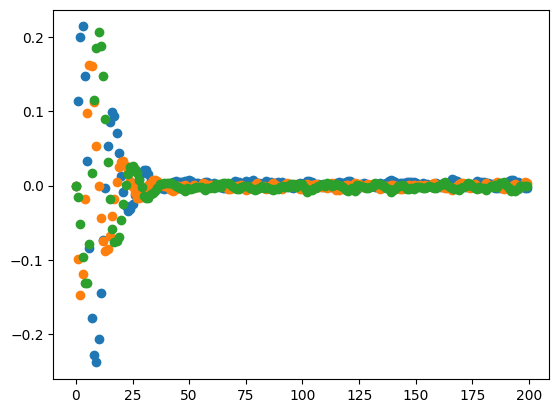

In [117]:
# residue scatter plot
import matplotlib.pyplot as plt
res = r.reshape((T_end,3))
for i in range(3):
    plt.scatter(t_data,res[:,i])

The error/residue is not showing any pattern.

In [120]:
#simulation
theta= [0.16713468, 0.1224545,  0.31732589]
x0 = [1,0,0]
def simulate(theta, t_eval, x0):
    alpha, beta, gamma = theta
    
    sol = solve_ivp(
        lambda t, x: system(t, x, alpha, beta, gamma),
        (t_eval[0], t_eval[-1]),
        x0,
        t_eval=t_eval
    )
    
    return sol.y.T   # shape: (n_time, 3)

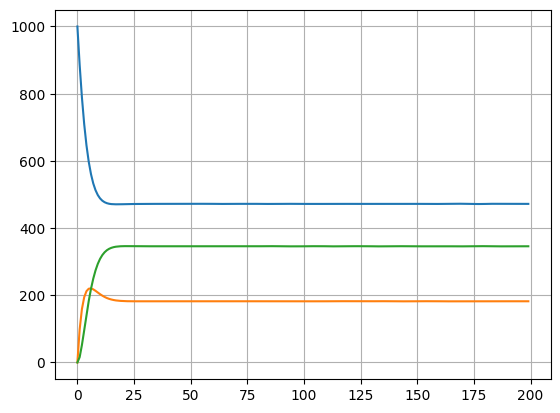

In [121]:
Y = simulate(theta, t_data, x0)
for i in range(3):
    plt.plot(t_data,Y[:,i]*N)
plt.grid()

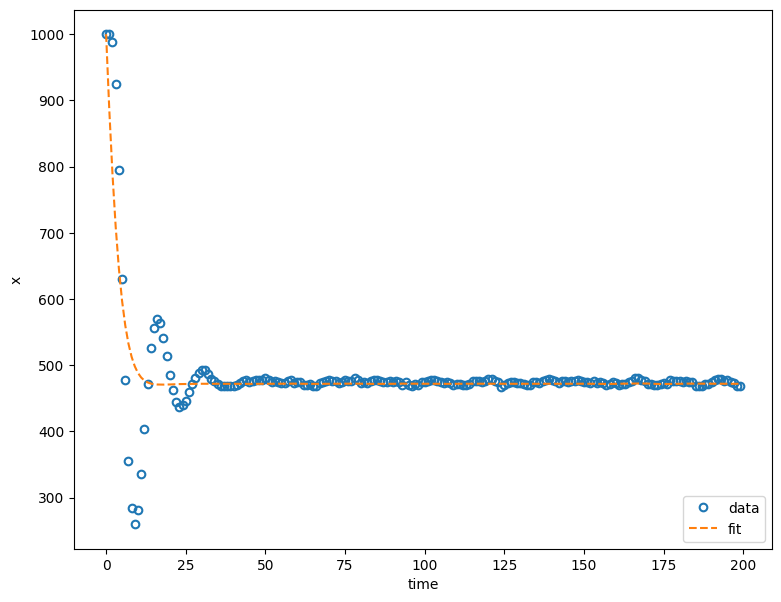

In [123]:
# Plot solution
fig, ax = plt.subplots(1,1,figsize=(9,7))

ax.plot(t_data, a*N, 'o', linewidth=1.5, mfc='none', ms=5.5, mew=1.5, label='data')
ax.plot(t_data, Y[:,0]*N, '--', linewidth=1.5, mfc='none', ms=5.5, mew=1.5, label='fit')

# Set axes labels and legends
ax.set_xlabel('time')
ax.set_ylabel('x')
ax.legend(loc='lower right')

plt.show()

In [ ]:
fig, axs = plt.subplots(8, 8, figsize=(8, 8))
for i, ax in enumerate(axs.ravel()):
    image= images[smpl_idx[i]]
    ax.imshow(image)
    ax.axis('off')
plt.tight_layout()

# III Parameter Sensitivity and Hair Treatment 